In [1]:
import pandas as pd
import re
import numpy as np
from scipy import stats
import itertools
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import to_hex

In [2]:
# Load data UTHealth
uthh = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/02trans_age-07272025/00uthhealth_rnaagecalc-07272025.csv")
# Rename the first column to SampleID
uthh.rename(columns={uthh.columns[0]: "SampleID"}, inplace=True)

# Load data GSE
gse = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/02trans_age-07272025/02gse102556-08052025.csv")
# Rename the first column to SampleID
gse.rename(columns={gse.columns[0]: "SampleID"}, inplace=True)

# Load data VABB
vabb = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/02trans_age-07272025/01vabb_rnaagecalc-07272025.csv")
# Rename the first column to SampleID
vabb.rename(columns={vabb.columns[0]: "SampleID"}, inplace=True)
# Replace the letter between numbers with an underscore
vabb["SampleID"] = vabb["SampleID"].str.replace(r"(?<=\d)[A-Z]+(?=\d)", "_", regex=True)

# Load data
dpclo = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/90summaries/00deepclock-08032025.csv")
# Rename and keep only SampleID and KPANN_brain columns
dpclo = dpclo.rename(columns={'ID': 'SampleID', 'Predicted': 'KPANN_brain'})[['SampleID', 'Age', 'KPANN_brain', 'Bank']]
# Add GSE from GEO cohort
# Load data
gse_kpann = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/90summaries/04gsecohort_kpnaa_clock_prediction-08052025.txt", sep = '\t')
gse_kpann = gse_kpann.rename(columns={'ID': 'SampleID', 'Predicted': 'KPANN_brain'})[['SampleID', 'Age', 'KPANN_brain', 'Bank']]
# Concatenate data
# Concatenate rows
kpann = pd.concat([dpclo, gse_kpann], axis=0, ignore_index=True)

# Merge with both filtered datasets
merged_df_com = pd.merge(kpann, uthh, on='SampleID')
merged_df2_com = pd.merge(kpann, vabb, on='SampleID')
merged_df3_com = pd.merge(kpann, gse, on='SampleID')
print(merged_df_com.shape)
print(merged_df2_com.shape)
print(merged_df3_com.shape)

(89, 212)
(546, 212)
(96, 219)


In [3]:
# --- 1. Subset relevant columns from both datasets ---
# Defining a function to extract the columns with brains and Age
def extract_age_and_brain(df, source_label):
    # Use 'AgeDeath' if available, otherwise fallback to 'Age'
    age_col = 'AgeDeath' if 'AgeDeath' in df.columns else 'Age'
    # Get columns that end with '_brain'
    brain_cols = [col for col in df.columns if col.endswith('_brain')]
    # Extract relevant columns
    subset = df[[age_col] + brain_cols].copy()
    # Rename age column to a common name
    subset.rename(columns={age_col: 'Age'}, inplace=True)
    # Drop rows with any NA values
    subset = subset.dropna()
    # Add source column
    subset['Source'] = source_label
    return subset

# Create subsets
uth_subset = extract_age_and_brain(merged_df_com, 'UTHealth')
vabb_subset = extract_age_and_brain(merged_df2_com, 'VABB')
gse_subset = extract_age_and_brain(merged_df3_com, 'GSE102556')
print(uth_subset.shape)
print(vabb_subset.shape)
print(gse_subset.shape)

# --- 2. Combine three datasets by row ---
# --- 1. Check column differences ---
cols_uth  = set(uth_subset.columns)
cols_vabb = set(vabb_subset.columns)
cols_gse  = set(gse_subset.columns)

print("Columns in UTH but not in VABB:", cols_uth - cols_vabb)
print("Columns in VABB but not in UTH:", cols_vabb - cols_uth)
print("Columns in UTH but not in GSE:", cols_uth - cols_gse)
print("Columns in GSE but not in UTH:", cols_gse - cols_uth)

# --- 2. Align all DataFrames to the same columns ---
# Union of all column names
all_cols = sorted(set(uth_subset.columns) | set(vabb_subset.columns) | set(gse_subset.columns))

# Reindex each DataFrame to have the same columns in the same order
uth_aligned  = uth_subset.reindex(columns=all_cols)
vabb_aligned = vabb_subset.reindex(columns=all_cols)
gse_aligned  = gse_subset.reindex(columns=all_cols)

# --- 3. Concatenate row-wise ---
combined_df = pd.concat([uth_aligned, vabb_aligned, gse_aligned], ignore_index=True)

(89, 11)
(546, 11)
(96, 11)
Columns in UTH but not in VABB: set()
Columns in VABB but not in UTH: set()
Columns in UTH but not in GSE: set()
Columns in GSE but not in UTH: set()


In [4]:
# Load data
dpclo2 = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/90summaries/00deepclock-08032025.csv")
# Rename and keep only SampleID and KPANN_brain columns
dpclo2 = dpclo2.rename(columns={'ID': 'SampleID', 'Predicted': 'KPANN_brain'})[['SampleID', 'Age', 'KPANN_brain', 'Bank', 'Type']]
# Add GSE from GEO cohort
# Load data
gse_kpann2 = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/90summaries/04gsecohort_kpnaa_clock_prediction-08052025.txt", sep = '\t')
gse_kpann2 = gse_kpann2.rename(columns={'ID': 'SampleID', 'Predicted': 'KPANN_brain'})[['SampleID', 'Age', 'KPANN_brain', 'Bank', 'Type']]
# Concatenate data
# Concatenate rows
kpann2 = pd.concat([dpclo2, gse_kpann2], axis=0, ignore_index=True)

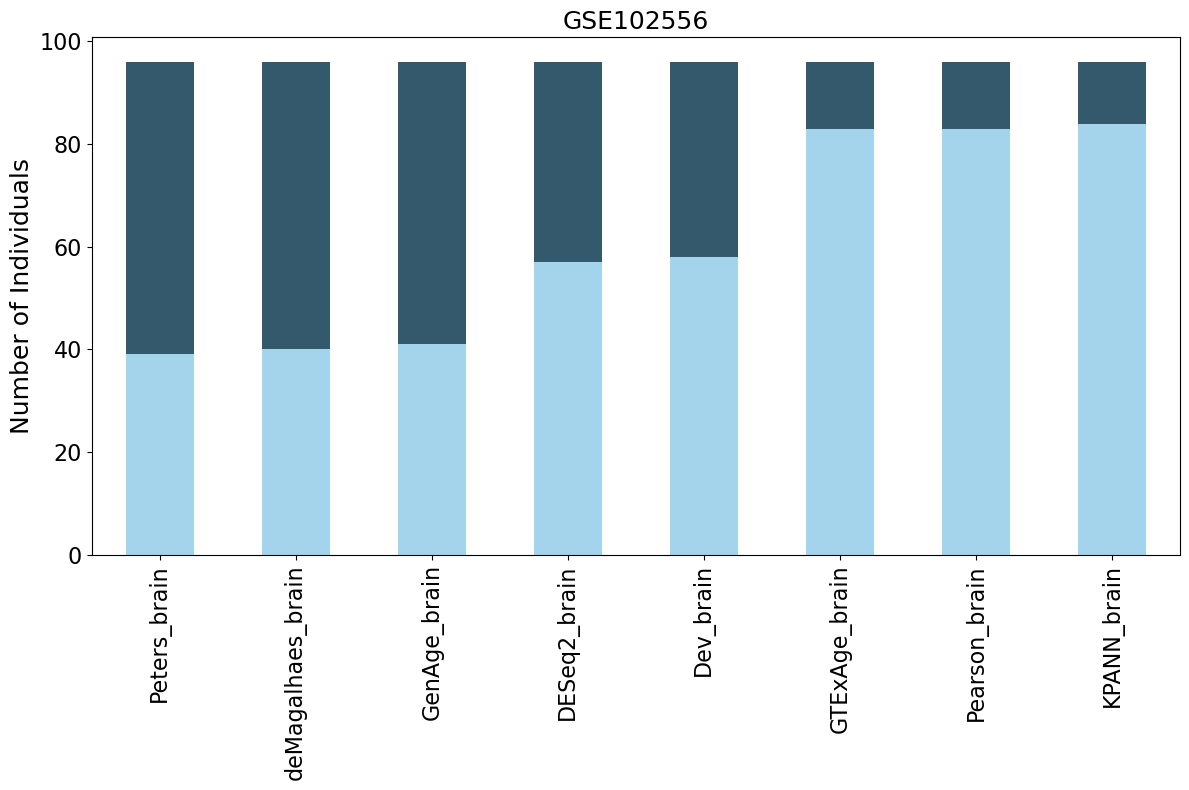

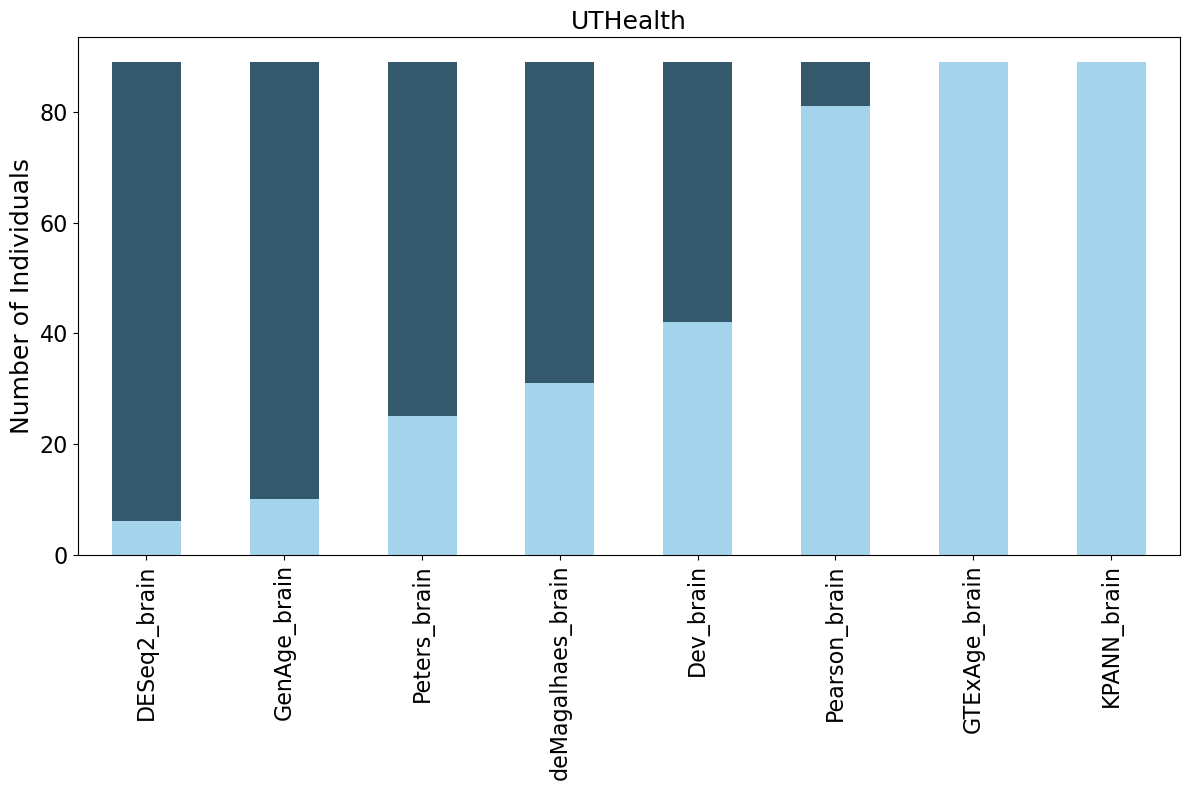

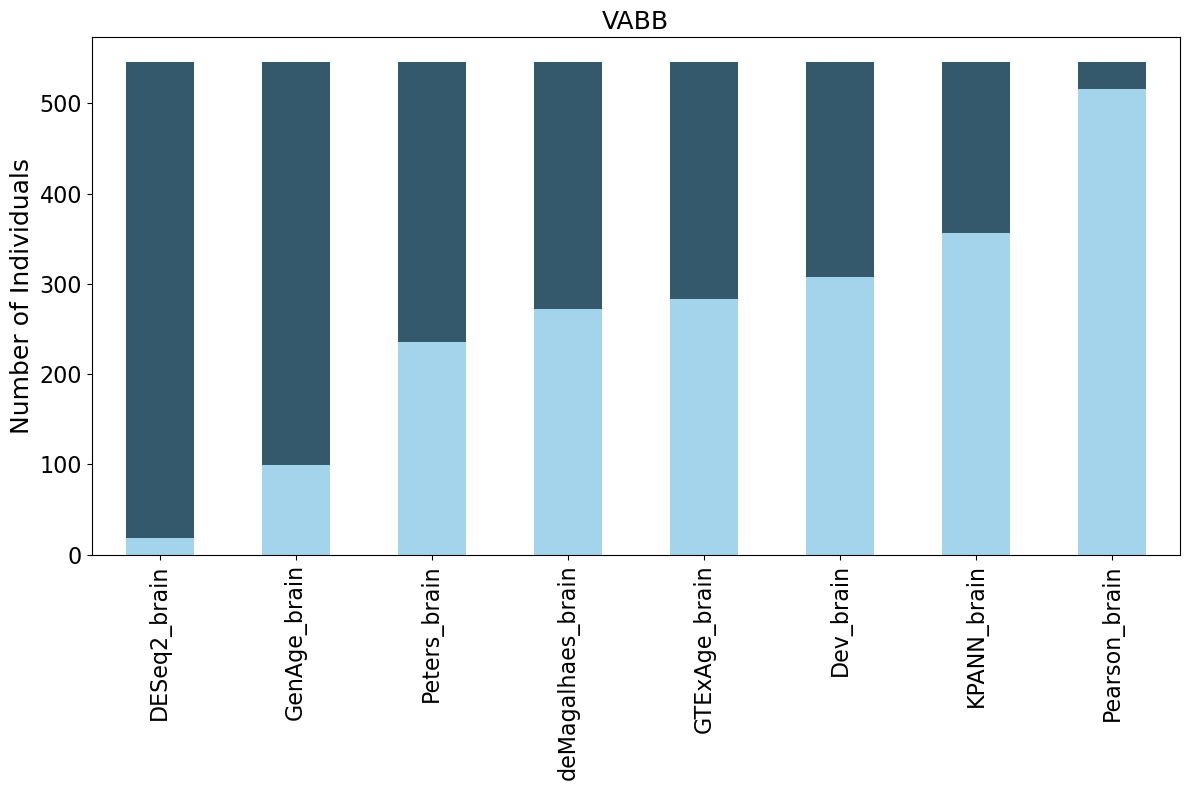

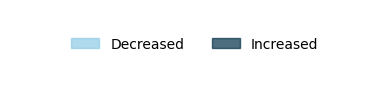

In [5]:
# --- Identify the clocks (all columns ending with "_brain", except "all_brain")
df = combined_df
# --- Identify the clocks (all columns ending with "_brain", except "all_brain")
clock_cols = [c for c in df.columns if c.endswith("_brain") and c not in ["all_brain"]]

# --- Melt into long format with delta-age
long_df = df.melt(
    id_vars=["Age", "Source"],
    value_vars=clock_cols,
    var_name="Clock",
    value_name="PredictedAge"
)

# Compute delta-age
long_df["DeltaAge"] = long_df["PredictedAge"] - long_df["Age"]

# Classify: increased, decreased, or no change
def classify_delta(x):
    if x > 0:
        return "Increased"
    elif x < 0:
        return "Decreased"
    else:
        return "No change"

long_df["Category"] = long_df["DeltaAge"].apply(classify_delta)

# --- Count number of individuals per Source × Clock × Category
count_df = (
    long_df.groupby(["Source", "Clock", "Category"])
    .size()
    .reset_index(name="Count")
)

# --- Plot stacked barplot
# Make sure categories are ordered consistently
category_order = ["Decreased", "Increased"]  # add "No change" if you included it
colors = {"Decreased": "#8ecae6", "Increased": "#023047"}  # fixed colors

for cohort in count_df["Source"].unique():
    cohort_df = count_df[count_df["Source"] == cohort]

    # Pivot so each clock has counts for each category
    pivot_df = cohort_df.pivot(index="Clock", columns="Category", values="Count").fillna(0)
    # Order rows (clocks) by Increased counts, descending
    if "Increased" in pivot_df.columns:
        pivot_df = pivot_df.sort_values(by="Increased", ascending=False)

    # Plot stacked bars
    ax = pivot_df[category_order].plot(
        kind="bar",
        stacked=True,
        figsize=(12,8),
        color=[colors[c] for c in category_order],
        alpha=0.8 
    )

    # Style
    plt.title(f"{cohort}", fontsize=18)
    plt.xlabel("")
    plt.ylabel("Number of Individuals", fontsize=18)
    plt.xticks(rotation=90, fontsize=16)
    plt.yticks(fontsize=16)
    plt.grid(False)
    plt.legend().remove()  # remove legend if you don’t want it
    plt.tight_layout()
    plt.savefig(f"00Fig4_{cohort}_stacked_barplot.pdf", dpi=600)
    plt.show()

# --- Dummy plot for legend only ---
fig, ax = plt.subplots(figsize=(4, 1))
handles = [plt.Rectangle((0,0),1,1, color=colors[c], alpha=0.7) for c in category_order]
labels = category_order
ax.legend(handles, labels, loc="center", frameon=False, ncol=len(category_order))
ax.axis("off")
plt.tight_layout()
plt.savefig("00Fig4_legend_only.pdf", dpi=600)
plt.show()

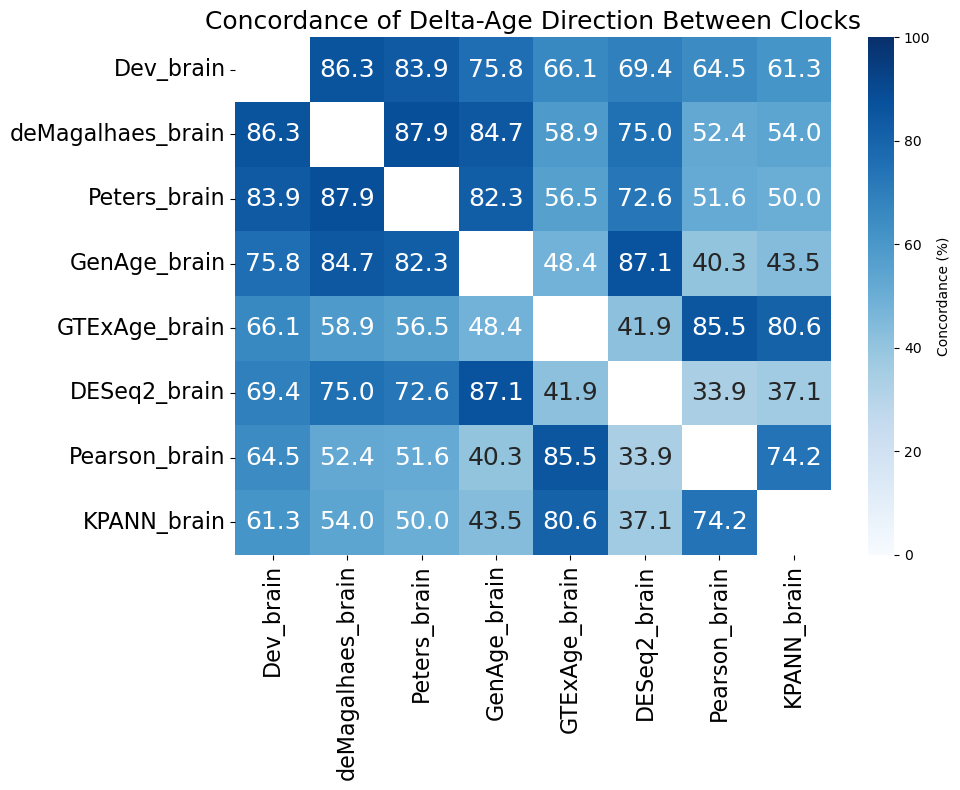

In [6]:
# Pivot long_df to have one row per individual and one column per clock with the Category
pivot_df = long_df.pivot_table(
    index=["Age", "Source"], 
    columns="Clock", 
    values="Category", 
    aggfunc='first'
).reset_index()

# Get all clock pairs
clocks = [c for c in pivot_df.columns if c not in ["Age", "Source"]]
pairs = list(itertools.combinations(clocks, 2))

# Compute concordance for each pair
concordance_list = []
for c1, c2 in pairs:
    valid_rows = pivot_df[[c1, c2]].dropna()  # drop rows with missing values
    concordant = (valid_rows[c1] == valid_rows[c2]).sum()
    total = len(valid_rows)
    percent = 100 * concordant / total
    concordance_list.append({"Clock1": c1, "Clock2": c2, "Concordance(%)": percent})

# Create a dataframe of concordances
concordance_df = pd.DataFrame(concordance_list)

# Optional: pivot to matrix format
concordance_matrix = concordance_df.pivot(index="Clock1", columns="Clock2", values="Concordance(%)")

# --- Pivot concordance_df to a square matrix (Clock1 × Clock2)
concordance_matrix = concordance_df.pivot(index="Clock1", columns="Clock2", values="Concordance(%)")

# --- Make the matrix symmetric
concordance_matrix = concordance_matrix.combine_first(concordance_matrix.T)

# --- Order clocks by mean concordance
mean_concordance = concordance_matrix.mean().sort_values(ascending=False)
ordered_clocks = mean_concordance.index.tolist()
concordance_matrix = concordance_matrix.loc[ordered_clocks, ordered_clocks]

# --- Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    concordance_matrix,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0, vmax=100,
    annot_kws={"fontsize":18},
    cbar_kws={"label": "Concordance (%)"}
)
# Increase colorbar label and tick fontsize
# Access the colorbar directly
cbar = ax.figure.axes[-1]  # last axes is usually the colorbar
cbar.set_ylabel("Concordance (%)", fontsize=20)  # label fontsize
cbar.tick_params(labelsize=20)                   # tick fontsize

plt.title("Concordance of Delta-Age Direction Between Clocks", fontsize=18)
plt.xticks(rotation=90, fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig("00Fig4_concordancematrix.pdf", dpi=600)
plt.show()

In [75]:
# List of clock columns
df = combined_df
# List of clocks
clocks = [
    "DESeq2_brain", "Dev_brain", "GTExAge_brain", "GenAge_brain",
    "KPANN_brain", "Pearson_brain", "Peters_brain", "deMagalhaes_brain"
]

# Your clocks
clocks = [
    "DESeq2_brain", "Dev_brain", "GTExAge_brain", "GenAge_brain",
    "KPANN_brain", "Pearson_brain", "Peters_brain", "deMagalhaes_brain"
]

# Compute delta categories
for clk in clocks:
    df[f"Delta_{clk}"] = df[clk] - df["Age"]
    df[f"Cat_{clk}"] = df[f"Delta_{clk}"].apply(
        lambda x: "Increased" if x > 0 else ("Decreased" if x < 0 else "No change")
    )

pairwise_data = []
for clk1, clk2 in itertools.combinations(clocks, 2):
    temp = df[["Age", f"Cat_{clk1}", f"Cat_{clk2}"]].copy()
    temp["Clock_Pair"] = f"{clk1} / {clk2}"
    temp["Concordance_Category"] = temp[f"Cat_{clk1}"] + " / " + temp[f"Cat_{clk2}"]
    pairwise_data.append(temp[["Age", "Clock_Pair", "Concordance_Category"]])

long_df = pd.concat(pairwise_data, ignore_index=True)

# Sort concordance categories consistently (without No change)
categories_ordered = [
    "Decreased / Decreased",
    "Decreased / Increased",
    "Increased / Decreased",
    "Increased / Increased"
]

# Set style and palette
sns.set(style="whitegrid", font_scale=1.8)
palette = sns.color_palette("Set1", n_colors=len(categories_ordered))

# Loop through each clock pair
for clk_pair in long_df["Clock_Pair"].unique():
    df_sub = long_df[long_df["Clock_Pair"] == clk_pair]
    
    plt.figure(figsize=(10,6))
    
    # Violin plot
    sns.violinplot(
        data=df_sub,
        x="Age",
        y="Concordance_Category",
        order=categories_ordered,
        hue="Concordance_Category",
        palette=palette,
        inner=None,
        density_norm="width",
        dodge=False,
        legend=False,
        alpha=0.4
    )
    
    # Jittered points
    sns.stripplot(
        data=df_sub,
        x="Age",
        y="Concordance_Category",
        order=categories_ordered,
        color="k",
        size=3,
        alpha=0.2,
        jitter=True
    )
    
    plt.xlabel("Chronological Age", fontsize=16)
    plt.ylabel("")
    plt.title(f"Actual Age by Delta-Age Concordance\n{clk_pair}", fontsize=20)
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    
    # Save figure
    filename = f"violin_{clk_pair.replace('/', '_')}.pdf"
    plt.savefig(filename, dpi=600)
    plt.close()

C:\Users\jjm262\AppData\Local\Temp\1\ipykernel_29112\3383313554.py:50: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.violinplot(
C:\Users\jjm262\AppData\Local\Temp\1\ipykernel_29112\3383313554.py:50: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.violinplot(
C:\Users\jjm262\AppData\Local\Temp\1\ipykernel_29112\3383313554.py:50: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.violinplot(
C:\Users\jjm262\AppData\Local\Temp\1\ipykernel_29112\3383313554.py:50: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.violinplot(
C:\Users\jjm262\AppData\Local\Temp\1\ipykernel_29112\3383313554.py:50: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.violinplot(
C:\Users\jjm262\AppData\Local\Temp\1\ipykernel_29112\3383313554.py:50: UserWarning: T

In [7]:
# Read both files
ret = 'C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/00RetrainedPredictions_gse102556-08172025.csv'
enRet = pd.read_csv(ret, index_col=0)
ret2 = 'C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/00RetrainedPredictions_uthealth-08182025.csv'
enRet2 = pd.read_csv(ret2, index_col=0)

# Add source column to each
enRet["Source"] = "GSE102556"
enRet2["Source"] = "UTHealth"

# Concatenate along rows (so Source column is preserved)
combined_df2 = pd.concat([enRet, enRet2], axis=0, ignore_index=False)

# Reset index if you want a clean continuous index
combined_df2.reset_index(inplace=True)
combined_df2.rename(columns={"index": "SampleID"}, inplace=True)
combined_df2

,SampleID,Actual_Age,Predicted_ElasticNet,Predicted_DeepLearning,Predicted_ElasticNet_Stochastic,Predicted_DeepLearning_Stochastic,Source
0,S14.BA11,47,47.286596,46.053800,21.956768,22.953129,GSE102556
1,S17.BA11,41,40.909524,22.240500,26.519688,25.946888,GSE102556
2,S20.BA11,31,32.850170,27.220861,14.666239,16.698282,GSE102556
3,S23.BA11,19,23.948171,23.157152,19.274508,21.772709,GSE102556
4,S28.BA11,46,45.836763,37.918415,25.872570,24.990147,GSE102556
...,...,...,...,...,...,...,...
180,A67995,63,50.348354,41.703583,30.864792,31.065182,UTHealth
181,A67996,36,49.019974,29.035337,23.333821,21.391320,UTHealth
182,A67997,61,48.260497,27.981165,23.822408,22.541843,UTHealth
183,A67998,28,35.980747,36.136463,17.568902,17.257830,UTHealth


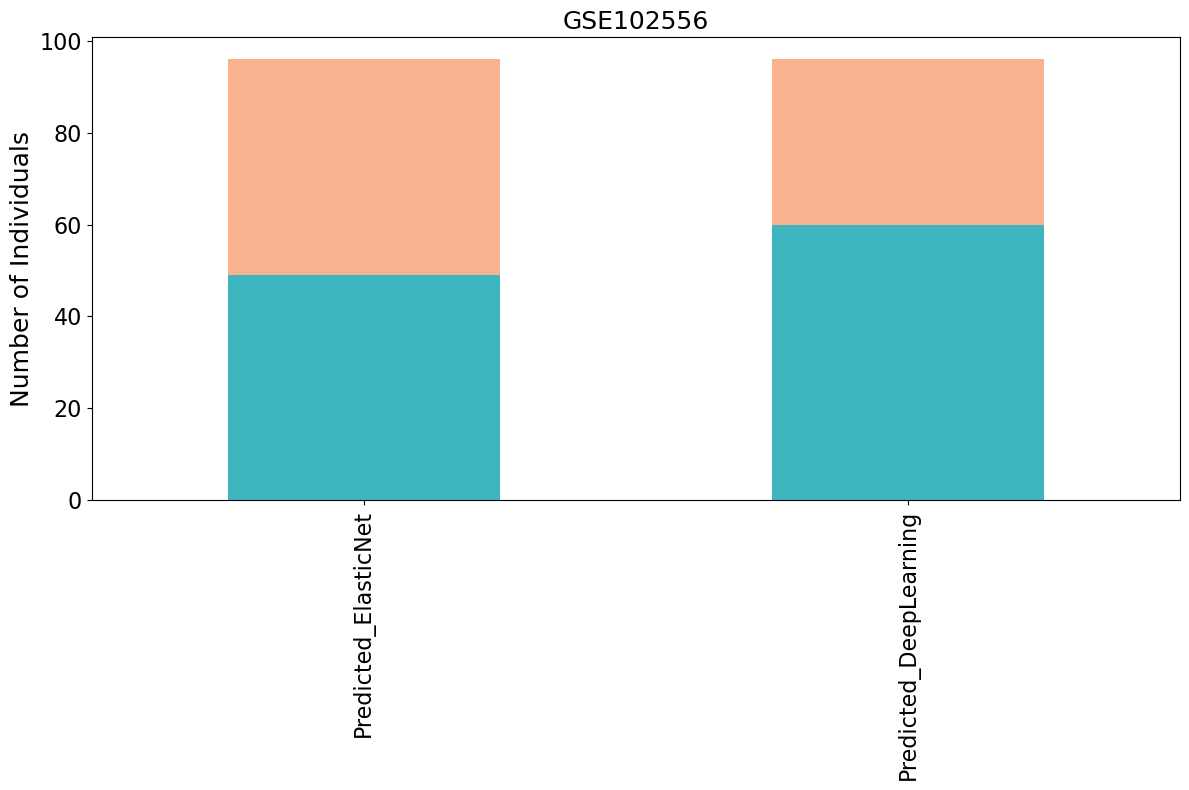

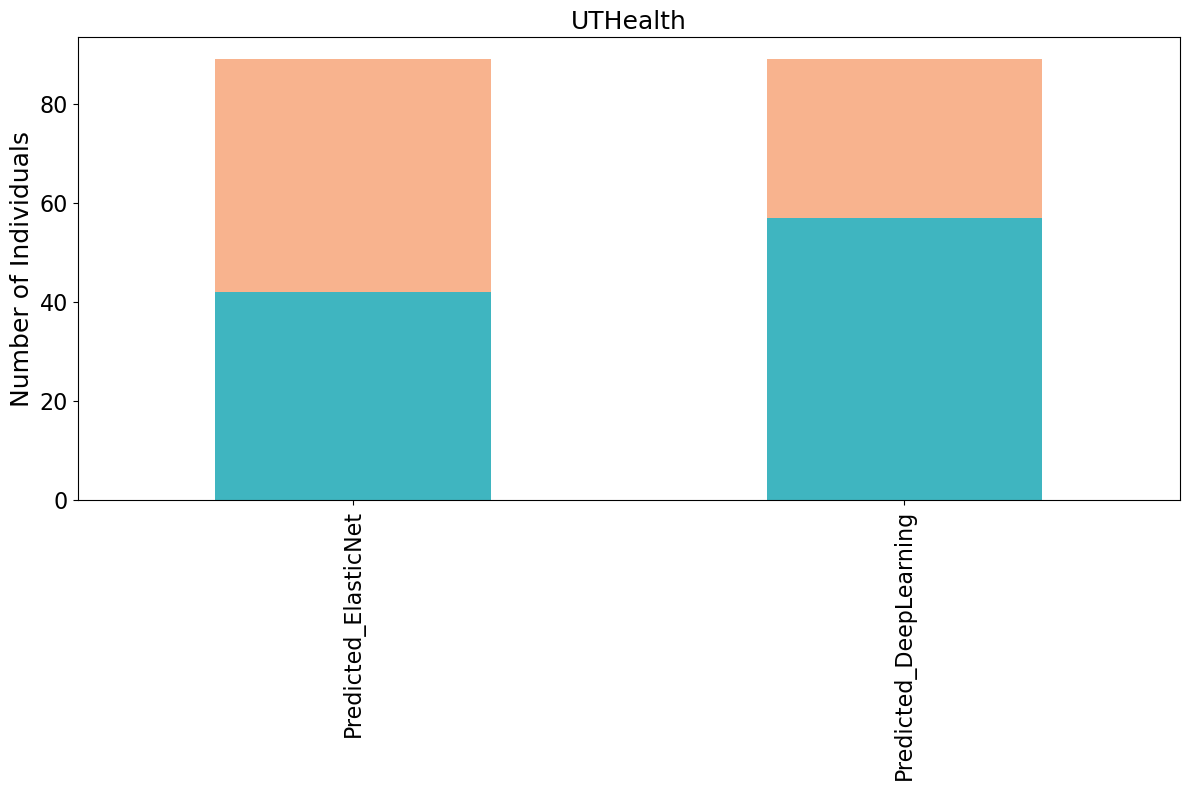

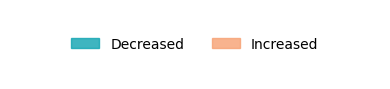

In [8]:
df = combined_df2  # replace with your actual dataframe variable

# --- Identify the clocks (only ElasticNet and DeepLearning, no stochastic)
clock_cols = ["Predicted_ElasticNet", "Predicted_DeepLearning"]

# --- Melt into long format with delta-age
long_df = df.melt(
    id_vars=["Actual_Age", "Source"],
    value_vars=clock_cols,
    var_name="Clock",
    value_name="PredictedAge"
)

# Compute delta-age
long_df["DeltaAge"] = long_df["PredictedAge"] - long_df["Actual_Age"]

# Classify: increased, decreased, or no change
def classify_delta(x):
    if x > 0:
        return "Increased"
    elif x < 0:
        return "Decreased"
    else:
        return "No change"

long_df["Category"] = long_df["DeltaAge"].apply(classify_delta)

# --- Count number of individuals per Source × Clock × Category
count_df = (
    long_df.groupby(["Source", "Clock", "Category"])
    .size()
    .reset_index(name="Count")
)

# --- Plot stacked barplot
category_order = ["Decreased", "Increased"]  # add "No change" if you want it
colors = {"Decreased": "#0fa3b1", "Increased": "#f7a072"}

for cohort in count_df["Source"].unique():
    cohort_df = count_df[count_df["Source"] == cohort]

    # Pivot so each clock has counts for each category
    pivot_df = cohort_df.pivot(index="Clock", columns="Category", values="Count").fillna(0)

    # 🔑 Order by Increased counts
    if "Increased" in pivot_df.columns:
        pivot_df = pivot_df.sort_values(by="Increased", ascending=False)

    # Plot stacked bars
    ax = pivot_df[category_order].plot(
        kind="bar",
        stacked=True,
        figsize=(12,8),
        color=[colors[c] for c in category_order],
        alpha=0.8
    )

    plt.title(f"{cohort}", fontsize=18)
    plt.xlabel("")
    plt.ylabel("Number of Individuals", fontsize=18)
    plt.xticks(rotation=90, fontsize=16)
    plt.yticks(fontsize=16)
    plt.grid(False)
    plt.legend().remove()

    plt.tight_layout()
    plt.savefig(f"00Fig4_{cohort}_stacked_barplot_retrained.pdf", dpi=600)
    plt.show()

# --- Dummy plot for legend only ---
fig, ax = plt.subplots(figsize=(4, 1))
handles = [plt.Rectangle((0,0),1,1, color=colors[c], alpha=0.8) for c in category_order]
labels = category_order
ax.legend(handles, labels, loc="center", frameon=False, ncol=len(category_order))
ax.axis("off")
plt.tight_layout()
plt.savefig("00Fig4_legend_only_retrained.pdf", dpi=600)
plt.show()

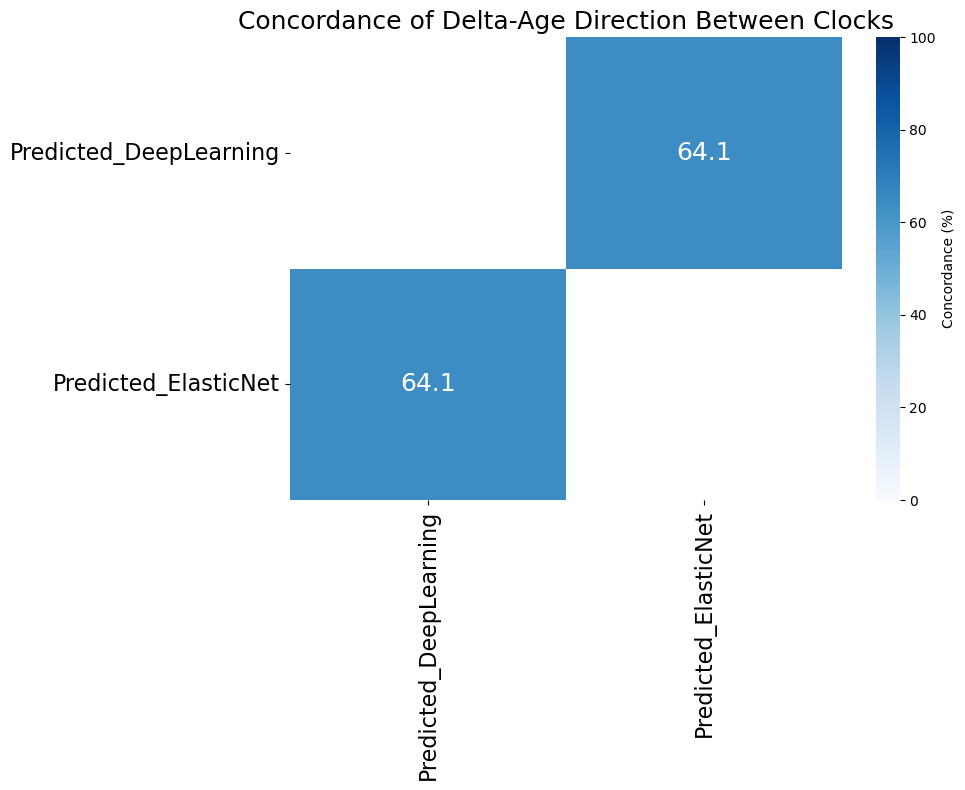

In [10]:
# Pivot long_df to have one row per individual and one column per clock with the Category
pivot_df = long_df.pivot_table(
    index=["Actual_Age", "Source"], 
    columns="Clock", 
    values="Category", 
    aggfunc='first'
).reset_index()

# Get all clock pairs
clocks = [c for c in pivot_df.columns if c not in ["Actual_Age", "Source"]]
pairs = list(itertools.combinations(clocks, 2))

# Compute concordance for each pair
concordance_list = []
for c1, c2 in pairs:
    valid_rows = pivot_df[[c1, c2]].dropna()  # drop rows with missing values
    concordant = (valid_rows[c1] == valid_rows[c2]).sum()
    total = len(valid_rows)
    percent = 100 * concordant / total
    concordance_list.append({"Clock1": c1, "Clock2": c2, "Concordance(%)": percent})

# Create a dataframe of concordances
concordance_df = pd.DataFrame(concordance_list)

# Optional: pivot to matrix format
concordance_matrix = concordance_df.pivot(index="Clock1", columns="Clock2", values="Concordance(%)")

# --- Pivot concordance_df to a square matrix (Clock1 × Clock2)
concordance_matrix = concordance_df.pivot(index="Clock1", columns="Clock2", values="Concordance(%)")

# --- Make the matrix symmetric
concordance_matrix = concordance_matrix.combine_first(concordance_matrix.T)

# --- Order clocks by mean concordance
mean_concordance = concordance_matrix.mean().sort_values(ascending=False)
ordered_clocks = mean_concordance.index.tolist()
concordance_matrix = concordance_matrix.loc[ordered_clocks, ordered_clocks]

# --- Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    concordance_matrix,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0, vmax=100,
    annot_kws={"fontsize":18},
    cbar_kws={"label": "Concordance (%)"}
)
# Increase colorbar label and tick fontsize
# Access the colorbar directly
cbar = ax.figure.axes[-1]  # last axes is usually the colorbar
cbar.set_ylabel("Concordance (%)", fontsize=20)  # label fontsize
cbar.tick_params(labelsize=20)                   # tick fontsize

plt.title("Concordance of Delta-Age Direction Between Clocks", fontsize=18)
plt.xticks(rotation=90, fontsize=16)
plt.yticks(rotation=0, fontsize=16)
plt.tight_layout()
plt.savefig("00Fig4_concordancematrix_retrained.pdf", dpi=600)
plt.show()

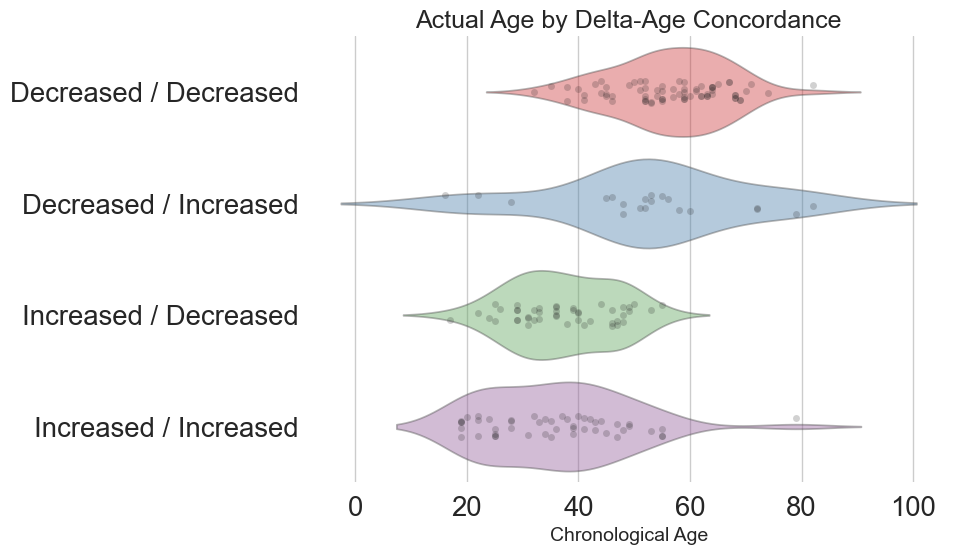

In [66]:
# ----------------------------------------
# Density Plots
# ----------------------------------------
df = combined_df2
clock1 = "Predicted_ElasticNet"
clock2 = "Predicted_DeepLearning"

# Compute delta-age
df["Delta_" + clock1] = df[clock1] - df["Actual_Age"]
df["Delta_" + clock2] = df[clock2] - df["Actual_Age"]

# Classify delta
def classify_delta(x):
    if x > 0:
        return "Increased"
    elif x < 0:
        return "Decreased"
    else:
        return "No change"

df["Cat_" + clock1] = df["Delta_" + clock1].apply(classify_delta)
df["Cat_" + clock2] = df["Delta_" + clock2].apply(classify_delta)

# Concordance category
df["Concordance_Category"] = df["Cat_" + clock1] + " / " + df["Cat_" + clock2]

# Sort categories (concordant decreased at bottom)
categories_ordered = [
    "Decreased / Decreased",
    "Decreased / Increased",
    "Increased / Decreased",
    "Increased / Increased"
]

df["Concordance_Category"] = pd.Categorical(df["Concordance_Category"],
                                            categories=categories_ordered,
                                            ordered=True)


# Set style
sns.set(style="whitegrid", font_scale=1.8)

# Define palette
palette = sns.color_palette("Set1", n_colors=len(categories_ordered))
plt.figure(figsize=(10,6))
sns.violinplot(
    data=df,
    x="Actual_Age",
    y="Concordance_Category",
    order=categories_ordered,
    hue="Concordance_Category",
    palette=palette,
    inner=None,
    density_norm="width",
    dodge=False,
    legend=False,
    alpha=0.4  # reduced transparency for violin
)

sns.stripplot(
    data=df,
    x="Actual_Age",
    y="Concordance_Category",
    order=categories_ordered,
    color="k",
    size=5,
    alpha=0.2,  # reduced transparency for points
    jitter=True
)

plt.xlabel("Chronological Age", fontsize=14)
plt.ylabel("")
plt.title("Actual Age by Delta-Age Concordance", fontsize=18)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig("00Fig4_density_retrained.pdf", dpi=600)
plt.show()